In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [2]:
df=pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Predictive Analytics Using Historical Data")
print("Sales Forecasting using Historical Data")

Predictive Analytics Using Historical Data
Sales Forecasting using Historical Data


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dt

In [5]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [6]:
df.dropna(inplace=True)

In [7]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [9]:
df['Order Date']=pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

In [10]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


In [11]:
df=df.sort_values(
'Order Date'
)

In [12]:
sales_data=df.groupby(
'Order Date'
)['Sales'].sum().reset_index()

sales_data.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [13]:
sales_data['Days']=(
sales_data['Order Date']
-
sales_data['Order Date'].min()
).dt.days

In [14]:
X=sales_data[['Days']]

y=sales_data['Sales']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,
test_size=0.2,
random_state=42
)

In [16]:
model=LinearRegression()

model.fit(
X_train,
y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred=model.predict(
X_test
)

In [18]:
print(
"R2 Score:",
r2_score(
y_test,
y_pred
)
)

print(
"MAE:",
mean_absolute_error(
y_test,
y_pred
)
)

R2 Score: 0.04576968516152402
MAE: 1408.5778551329868


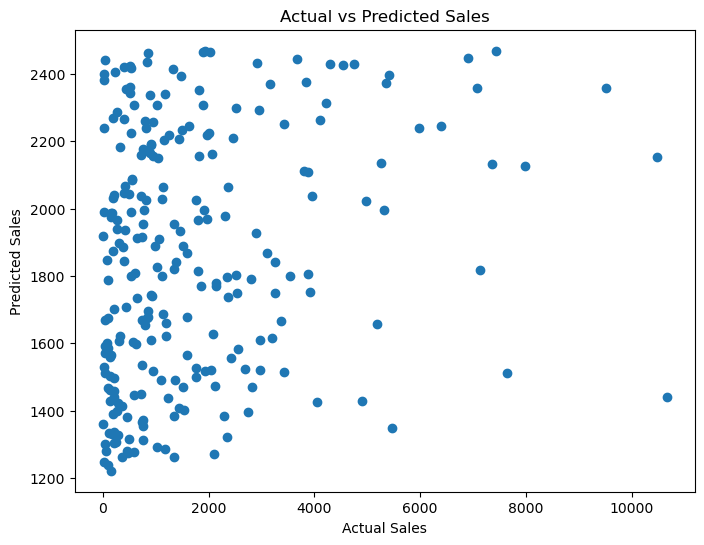

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
y_test,
y_pred
)

plt.xlabel(
"Actual Sales"
)

plt.ylabel(
"Predicted Sales"
)

plt.title(
"Actual vs Predicted Sales"
)

plt.show()

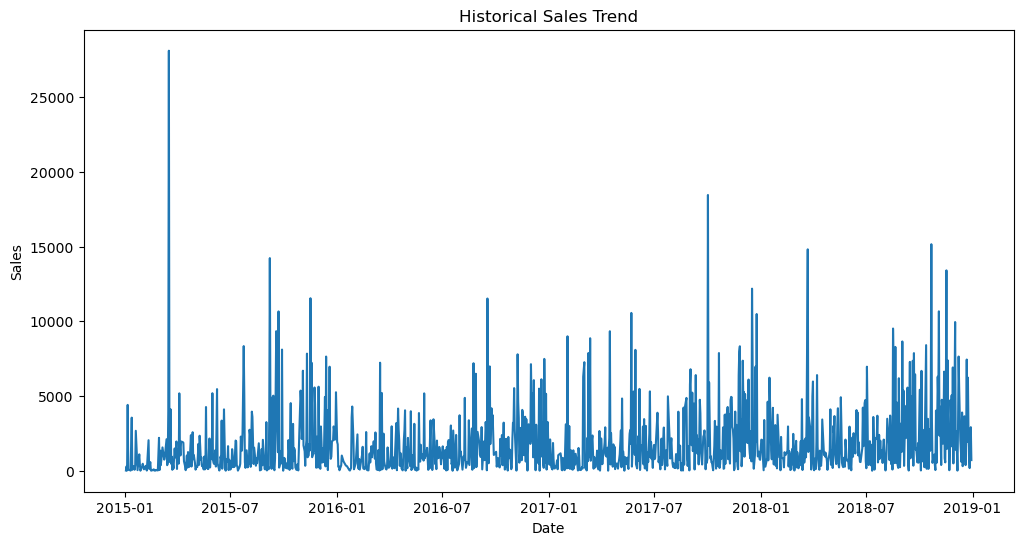

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
sales_data['Order Date'],
sales_data['Sales']
)

plt.xlabel(
"Date"
)

plt.ylabel(
"Sales"
)

plt.title(
"Historical Sales Trend"
)

plt.show()

In [21]:
future_days=np.array(
[[1500],
 [1600],
 [1700]]
)

future_sales=model.predict(
future_days
)

print(
future_sales
)

[2512.73054886 2599.53309648 2686.3356441 ]


C:\Users\kirta\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
